# 01. 규모효과 진단 — 왜 기본 회귀의 설명력이 낮았나

**질문**: 기본 회귀(analysis/00)의 R²가 0.07로 낮고, 유의한 변수도 거의 없다. 왜 그런가?

**가설**: 대부분 셀이 비슷한 **비율**로 줄었다면, 증감량(명)은 'GTX 접근성'보다 **2024년에 원래 몇 명이었나**로 정해진다.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # 정리본 최상위의 config.py

from config import *
setup_notebook()

import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats

data = load_model_data()  # data/processed/model_dataset.csv

corr(07~09시 증감, 2024년 승차) = -0.582


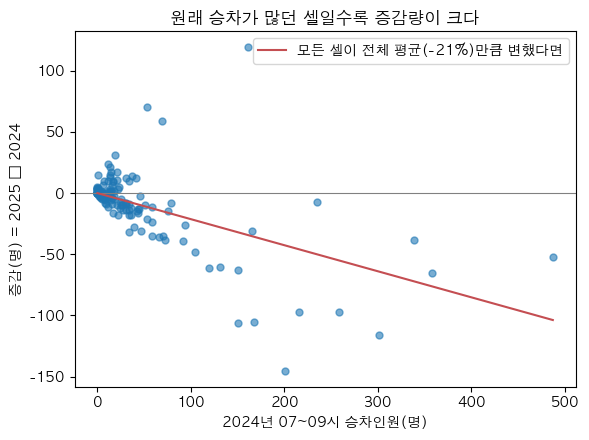

In [2]:
print(f"corr(07~09시 증감, 2024년 승차) = {data.change.corr(data.board_2024):.3f}")
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(data.board_2024, data.change, s=25, alpha=0.6)
ax.axhline(0, color="gray", linewidth=0.8)
x = np.linspace(0, data.board_2024.max(), 10)
overall = data.board_2025.sum() / data.board_2024.sum() - 1
ax.plot(x, x * overall, color="#C44E52", label=f"모든 셀이 전체 평균({overall*100:.0f}%)만큼 변했다면")
ax.set_xlabel("2024년 07~09시 승차인원(명)")
ax.set_ylabel("증감(명) = 2025 − 2024")
ax.set_title("원래 승차가 많던 셀일수록 증감량이 크다")
ax.legend()
plt.tight_layout()
plt.show()

→ 점들이 빨간 선(같은 비율로 줄었을 때) 주변에 모여 있다. 증감량은 대부분 **규모 × 공통 감소율**로 설명된다.

In [3]:
models = {
    "A. 기본 본모형": X_MAIN,
    "B. 2024년 승차만": ["board_2024"],
    "C. 본모형 + 2024년 승차": X_MAIN + ["board_2024"],
}
fits = {name: sm.OLS(data.change, sm.add_constant(data[x])).fit(cov_type="HC3") for name, x in models.items()}
display(pd.DataFrame({"R2": {n: f.rsquared for n, f in fits.items()}, "adj R2": {n: f.rsquared_adj for n, f in fits.items()}}).round(3))
coef_table(fits["C. 본모형 + 2024년 승차"])

,R2,adj R2
A. 기본 본모형,0.075,0.038
B. 2024년 승차만,0.339,0.334
C. 본모형 + 2024년 승차,0.361,0.330


,coef,p,유의
const,3.4251,0.4935,
GTX역 보행시간(분),0.0661,0.1318,
IC까지 도로거리(km),-1.8522,0.0314,**
GTX 경쟁 목적지 비율(%),0.0049,0.9287,
2024년 20~50대 인구,0.0045,0.2967,
2024년 건축물 수,-0.0178,0.7671,
2024년 07~09시 승차,-0.2346,0.0006,***


→ 2024년 승차 하나만으로 R² ≈ 0.34이고, 여기에 본모형 변수 5개를 더해도 약 2%p만 오른다.
2024년 규모를 통제하면 **GTX 보행시간은 유의하지 않게 된다**(p≈0.13). 기본 회귀에서 보행시간이 유의했던 건 '역에서 먼 셀 = 원래 승차가 적은 셀'이라는 **규모 차이를 대신 잡은 것**일 가능성이 크다.

### 보조모형(감소 여부·감소규모)도 2024년 규모를 통제하면

In [4]:
logit = sm.Logit(data.decreased, sm.add_constant(data[X_MAIN + ["log_board_2024"]])).fit(disp=0, cov_type="HC1")
decreased = data[data.decreased == 1].assign(decrease=lambda d: -d.change)
scale = sm.OLS(decreased.decrease, sm.add_constant(decreased[X_MAIN + ["board_2024"]])).fit(cov_type="HC3")
print(f"감소 여부 로지스틱 pseudo R2 = {logit.prsquared:.3f} | 감소 셀 감소규모 R2 = {scale.rsquared:.3f}")
pd.concat({"감소 여부 (로지스틱)": coef_table(logit), "감소규모 (감소 셀 78개)": coef_table(scale)}, axis=1)

감소 여부 로지스틱 pseudo R2 = 0.267 | 감소 셀 감소규모 R2 = 0.511


감소 여부 (로지스틱)              감소규모 (감소 셀 78개)             
                               coef       p   유의            coef       p   유의
const                       -1.0059  0.1970               5.5763  0.4158     
GTX역 보행시간(분)                -0.0094  0.0767    *         -0.1107  0.1204     
IC까지 도로거리(km)                0.1323  0.1480               1.6972  0.0658    *
GTX 경쟁 목적지 비율(%)            -0.0039  0.6716               0.0648  0.5035     
2024년 20~50대 인구             -0.0007  0.0961    *         -0.0028  0.5506     
2024년 건축물 수                 -0.0118  0.1252               0.0554  0.5185     
log(1+2024년 07~09시 승차)       0.8316  0.0000  ***             NaN     NaN  NaN
2024년 07~09시 승차                 NaN     NaN  NaN          0.2224  0.0047  ***

## 결론
- 두 보조모형 모두 **2024년 규모만 유의**하다. 원래 승차가 많던 셀이 '감소 셀'이 되기 쉽고, 감소량도 크다.
- 증감량(명)이나 감소 여부를 종속변수로 쓰면 X 변수들이 규모 효과에 묻힌다.
- 그래서 종속변수를 **변화율**로 바꾼다 → `02_변화율모형_오전_종일.ipynb`